# Data Visualization - Part 1

Usaremos **matplotlib**, que es un API para graficas con apoyo de Numpy e inspirado en Matlab

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


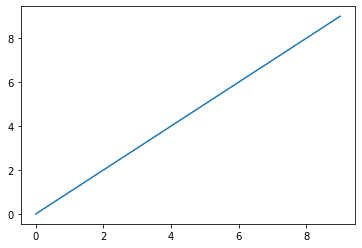

In [3]:
data = np.arange(10)
data
plt.plot(data)

Puedo añadir información de título y ejes a la gráfica con los siguientes métodos pero debo hacerlo al momento de cfrear la gráfica. De lo contrario, se creará una imagen nueva (sin data):

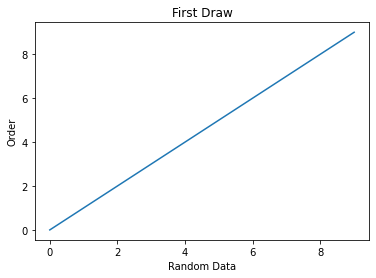

In [7]:
plt.plot(data)
plt.title('First Draw')
plt.xlabel('Random Data')
plt.ylabel('Order');

La anterior se conoce como la "forma implícita" de desplegar las gráficas. Es implicita pues los métodos y estilos usados se oscurecen. Además, si queremos hacer modificaciones necesitamos recuperar el eje y solo podemos acceder al último en el stack. También podemos asignar cada figura a un "handle" individual, coo sigue:

In [9]:
fig = plt.figure()

<Figure size 432x288 with 0 Axes>

Puedo crear "subfiguras" dentro de una misma figura, sea haciendo cada figura con un estilo distinto o la misma manera de representarlas. Para esto, debo indicar como quiero dividir la figura. Es decir, en cuantas cuadrículas quiero partir la imagen y como quiero distribuirlas, es decir, cuantas filas y columnas de imaégenes quiero crear. Debo indicar, además, en que posición de esa cuadrícula quiero colocr la imagen que estoy creando.

In [10]:
ax1 = fig.add_subplot(2, 2, 1)

In [11]:
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2,2, 3)

Note que puedo crear todas las divisiones primero y luego crear las imágenes, o puedo hacer las imágenes en el momneto de la división, como se prefiera.

Podemos especificar los colores con su nombre, convención RGD, notación hexadecimal o inicial. Además, terminar las instrucciones con ; suprime el output. En el caso de las gráficas, suprime el despliegue de los cómputos de los ejes. Puede verificar la diferencia eliminando el ; . Esto es particularmente conveniente con la notación implícita y con cómputos intermedios.

In [12]:
ax3.plot(np.random.standard_normal(50).cumsum(), color="#000000",
         linestyle="dotted");

In [13]:
ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3);
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30));

Si acaso queremos modificar las dimensiones de un grid ya creado, podemos hacerlo pero se distorsionaran las figuras:

In [14]:
ax4 = fig.add_subplot(2, 3, 4)

In [15]:
ax4.scatter(np.arange(10), np.arange(10) + 8 * np.random.standard_normal(10));

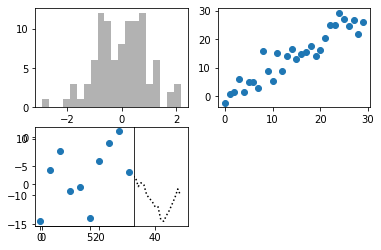

In [16]:
fig

La versión implícita de lo anterior (recuperando los ejes) sería como sigue:

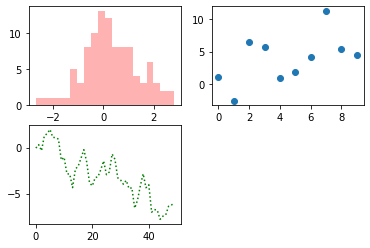

In [17]:
plt.subplot(2, 2, 1)
ax_1 = plt.gca()
ax_1.hist(np.random.standard_normal(100), bins=20, color="red", alpha=0.3);

plt.subplot(2, 2, 2)
ax_2 = plt.gca()
ax_2.scatter(np.arange(10), np.arange(10) + 3 * np.random.standard_normal(10));

plt.subplot(2, 2, 3)
ax_3 = plt.gca()
ax_3.plot(np.random.standard_normal(50).cumsum(), color="green",
         linestyle="dotted");

Hemos visto como crear líneas, "scatter plot" e histogramas. Vamos a completar el grid añadiendo un diagrama de barras en la cuarta cuadrícula. Note que la división anterior permanece, lo cual puede usarse cuando quiero que alguna cuadrícula renga tamaño y estructura distinta a las demás:

In [18]:
np.random.seed(3)
# número de barras
x = 0.5 + np.arange(8)
# altura de cada barra de manera aleatoria pero entre 2 - 7
y = np.random.uniform(2, 7, len(x))

ax4 = fig.add_subplot(2, 2, 4)
ax4.bar(x, y, width=1, edgecolor="white", linewidth=0.5);

ax4.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8));

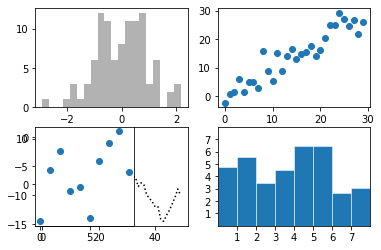

In [19]:
fig

In [14]:
# 'Libero' el stack
plt.close("all")

Forma Explícita: crear ejes de antemano. Esta es la manera recomendada y la que me permite mayor flexibilidad de hacer modificaciones posteriores. En la forma explícita obtengo un arreglo con la información de los ejes de cada cuadrícula creada (axes) y el "handle" (objeto) de la figura.

array([[<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>]], dtype=object)

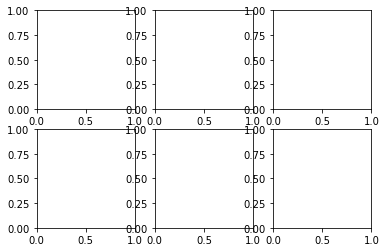

In [96]:
fig, axes = plt.subplots(2, 3)
axes

Usando la forma explícita anterior, puedo crear y modificar de manera independiente cada figura. En caso de que todas las cuadrículas contengan el mismo tipo de gráfica, puedo usarlas en un ciclo accediendo los ejes en el arreglo. Si las figuras forman una sola línea, uso un arreglo unidimensional (vector). Si tengo mas de una fila, uso un arreglo de dos dimensiones para acceder los ejes:

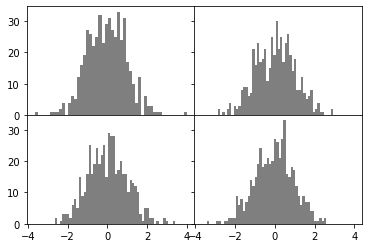

In [17]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.standard_normal(500), bins=50,
                        color="black", alpha=0.5)
fig.subplots_adjust(wspace=0, hspace=0)

In [102]:
# Estoy reusando el nombre "fig". Si quiere hacer figuras distintas o que no se les modifiquen las anteriores, use "fig1", "fig2", etc...
fig = plt.figure()

<Figure size 432x288 with 0 Axes>

In [103]:
ax = fig.add_subplot()
ax.plot(np.random.standard_normal(30).cumsum(), color="black",
        linestyle="dashed", marker="o");

También puedo escribir los parámetros anteriores como (color(k es negro), marker (o,*,+,x,-,., etc), estilo de línea(-,--,:).El siguiente es un código mas simple pero limita mas las combinacioned de estilos:

In [104]:
ax.plot(np.random.standard_normal(30).cumsum(), 'gp:');

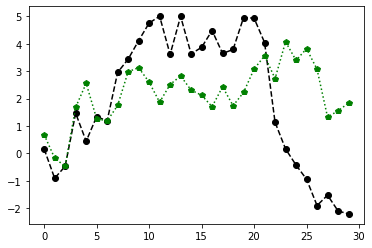

In [105]:
fig

In [106]:
plt.close("all")

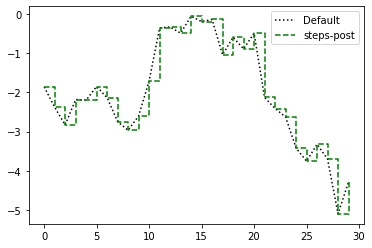

In [32]:
# Si quiero representar varias gráficas en la misma figura, 're-uso' el eje. Conveniente para análisis.
fig = plt.figure()
ax = fig.add_subplot()
data = np.random.standard_normal(30).cumsum()
ax.plot(data, color="black", linestyle="dotted", label="Default"); #label para desplegar en leyenda
ax.plot(data, color="green", linestyle="dashed",
        drawstyle="steps-post", label="steps-post");
ax.legend(loc='best')

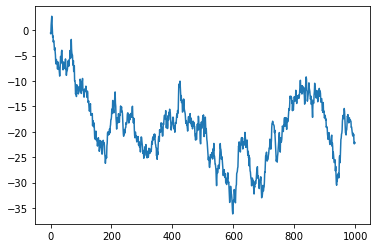

In [61]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())

In [62]:
# Puedo elegir la distancia entre las marcas en los ejes (ticks) y como nombrarlas (labels)
ticks = ax.set_xticks([0, 250, 500, 750, 1000]) # o ax.set_yticks
labels = ax.set_xticklabels(["one", "two", "three", "four", "five"],
                            rotation=30, fontsize=8) # o ax.set_ytickslabels

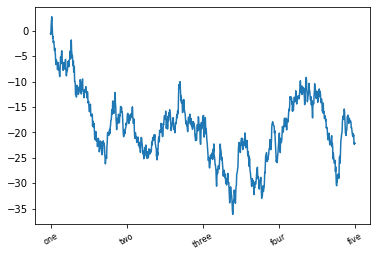

In [63]:
fig

In [64]:
# Para nombrar la gráfica y los ejes:
ax.set_xlabel("Stages")
ax.set_title("My first matplotlib plot")

Text(0.5, 1.0, 'My first matplotlib plot')

Note que cuando se nombran los ejes 

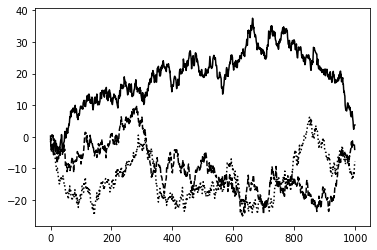

In [65]:
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color="black", label="one");
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dashed",
        label="two");
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dotted",
        label="three");

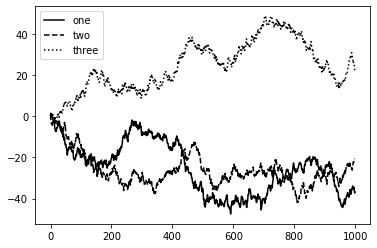

In [25]:
ax.legend()
fig